# 🏍️ Used Bike Price Prediction — End-to-End ML Project

**Goal:** Predict the resale price of used bikes in India.

**Dataset:** 7,857 listings · 8 raw features · Target: `price` (INR)

**Pipeline:**
1. Data Loading & EDA
2. Data Cleaning (strings → numerics, missing values)
3. Outlier Detection & Treatment
4. Feature Engineering
5. Encoding & Scaling
6. Model Training & Comparison
7. Cross-Validation
8. Hyperparameter Tuning
9. Feature Importance
10. Business Insights


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("Libraries loaded ✅")


Libraries loaded ✅


## 2. Load the Dataset

In [2]:
# Update path as needed
df = pd.read_csv(r"D:\Project File\Unified Mentor\Bike Prices\bikes.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (7857, 8)


,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


## 3. Exploratory Data Analysis

In [3]:
#  Basic info
df.info()
print()
print("Missing values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB

Missing values:
model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64


In [4]:
df.describe()


,model_year,price
count,7857.000000,7.857000e+03
mean,2015.367698,1.067913e+05
std,4.001443,1.389261e+05
min,1950.000000,0.000000e+00
25%,2014.000000,4.200000e+04
50%,2016.000000,7.500000e+04
75%,2018.000000,1.250000e+05
max,2021.000000,3.000000e+06


In [5]:
df.nunique()


model_name    1724
model_year      36
kms_driven    1801
owner            4
location       561
mileage        117
power          272
price         1627
dtype: int64

In [6]:
#  Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


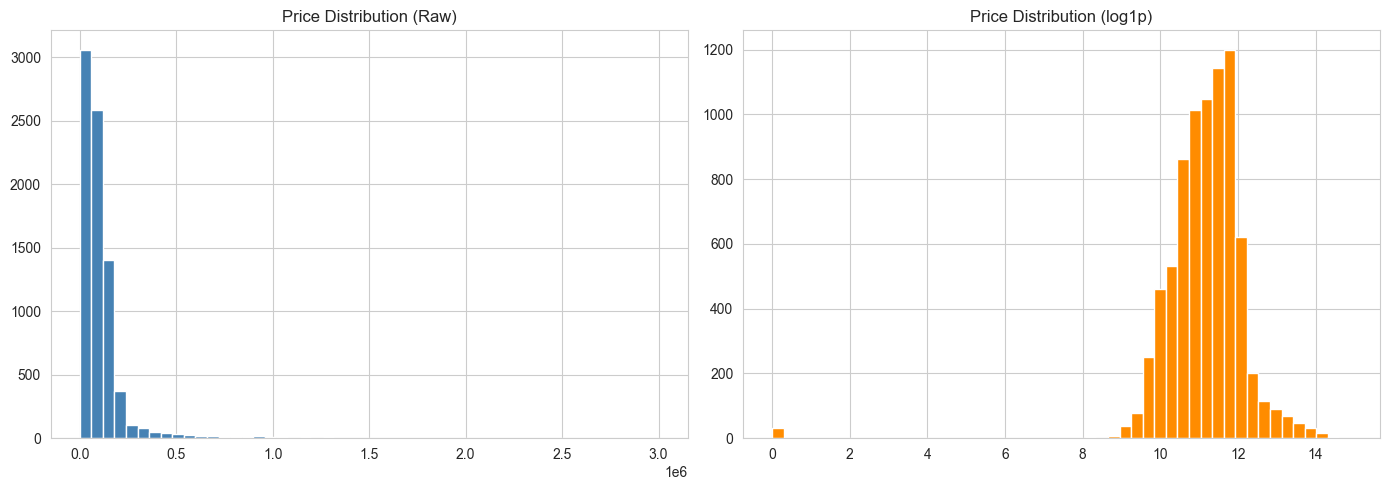

Price range: ₹0 ₹3,000,000
Median: ₹75,000.0


In [7]:
# Target distribution BEFORE log transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution (Raw)")
axes[1].hist(np.log1p(df["price"]), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Price Distribution (log1p)")
plt.tight_layout(); plt.show()
print(f"Price range: ₹{df['price'].min():,} ₹{df['price'].max():,}")
print(f"Median: ₹{df['price'].median():,}")


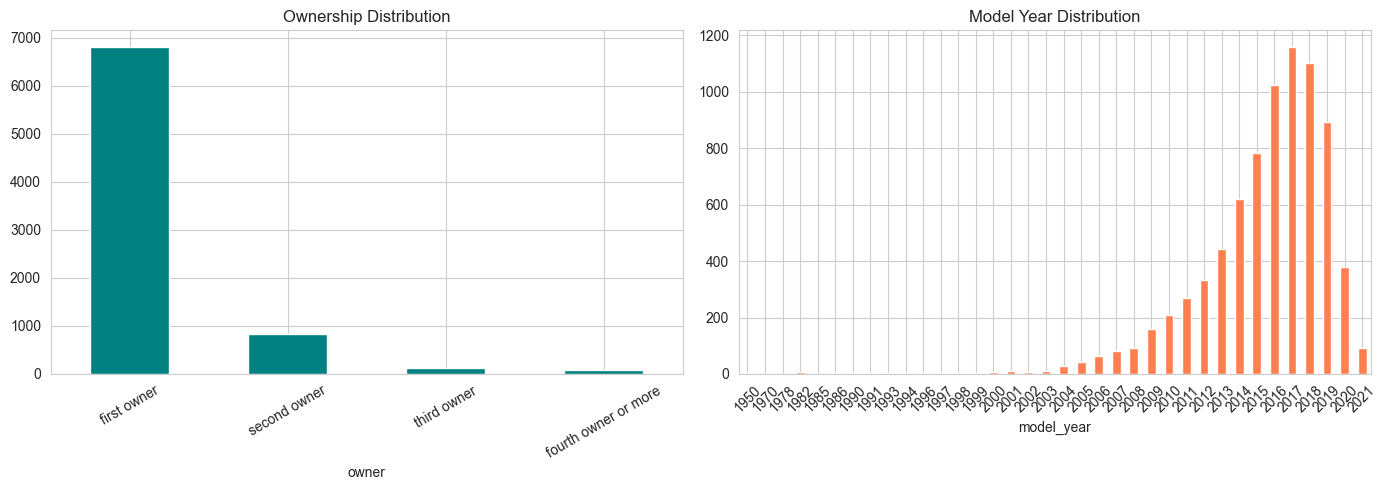

In [8]:
# Categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["owner"].value_counts().plot(kind="bar", ax=axes[0], color="teal", edgecolor="white")
axes[0].set_title("Ownership Distribution")
axes[0].tick_params(axis="x", rotation=30)
df["model_year"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Model Year Distribution")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


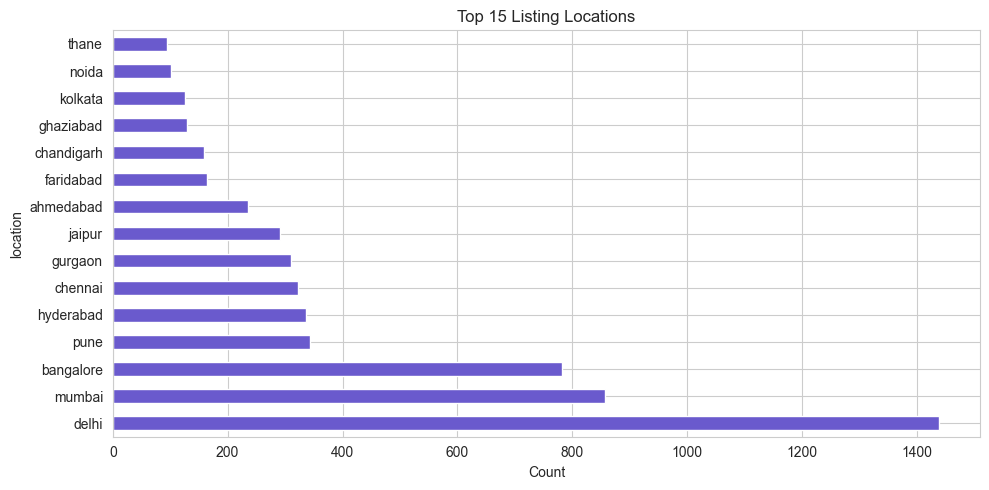

In [9]:
# Top 15 Locations
df["location"].value_counts().head(15).plot(kind="barh", figsize=(10, 5), color="slateblue", edgecolor="white")
plt.title("Top 15 Listing Locations")
plt.xlabel("Count")
plt.tight_layout(); plt.show()


## 4. Data Cleaning

In [10]:
# Drop duplicates
df.drop_duplicates(inplace=True)
print(f"After dedup: {df.shape}")


After dedup: (7857, 8)


In [11]:
# Clean kms_driven
df["kms_driven"] = df["kms_driven"].astype(str).str.extract(r"(\d+)")
df["kms_driven"] = pd.to_numeric(df["kms_driven"], errors="coerce")
print(df["kms_driven"].describe())


count       7854.000000
mean       17267.701935
std        26761.689455
min            0.000000
25%          104.000000
50%        11000.000000
75%        25000.000000
max      1000000.000000
Name: kms_driven, dtype: float64


In [12]:
#  Clean mileage
df["mileage"] = df["mileage"].astype(str).str.replace("kmpl", "", case=False)
df["mileage"] = df["mileage"].str.extract(r"(\d+\.?\d*)")
df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")
print(df["mileage"].describe())


count    7083.000000
mean       44.785635
std        16.986112
min         5.000000
25%        35.000000
50%        40.000000
75%        57.000000
max       104.000000
Name: mileage, dtype: float64


In [13]:
#  Clean power (bhp)
df["power"] = df["power"].astype(str).str.replace("bhp", "", case=False)
df["power"] = df["power"].str.extract(r"(\d+\.?\d*)")
df["power"] = pd.to_numeric(df["power"], errors="coerce")
print(df["power"].describe())


count    7826.000000
mean       20.765127
std        15.016736
min         6.100000
25%        14.000000
50%        19.000000
75%        24.160000
max       197.300000
Name: power, dtype: float64


In [14]:
# Cell 4.5  Extract engine CC
df["cc"] = df["model_name"].str.extract(r"(\d+)cc")
df["cc"] = pd.to_numeric(df["cc"], errors="coerce")
print(f"CC extracted for {df['cc'].notna().sum()} / {len(df)} rows")


CC extracted for 5649 / 7857 rows


In [15]:
#  Extract brand
df["brand"] = df["model_name"].apply(lambda x: str(x).split()[0])
print(df["brand"].value_counts().head(10))


brand
Bajaj              2105
Royal              1750
Hero                808
Yamaha              747
TVS                 567
Honda               530
KTM                 491
Suzuki              223
Harley-Davidson     171
UM                  128
Name: count, dtype: int64


In [16]:
# Fill missing values with median / mode
for col in ["mileage", "power", "kms_driven", "cc"]:
    df[col].fillna(df[col].median(), inplace=True)
df["location"].fillna(df["location"].mode()[0], inplace=True)
print("Missing after fill:")
print(df.isnull().sum())


Missing after fill:
model_name    0
model_year    0
kms_driven    0
owner         0
location      0
mileage       0
power         0
price         0
cc            0
brand         0
dtype: int64


## 5. Outlier Detection & Treatment

In [17]:
#  Price = 0 rows
print(f"Rows with price = 0: {(df['price'] == 0).sum()}")
df[df["price"] == 0][["model_name", "model_year", "price"]].head()


Rows with price = 0: 31


,model_name,model_year,price
4786,Bajaj Pulsar 180cc 2009,2009,0
6200,Hero Passion Xpro 110cc 2015,2015,0
6780,Hyosung GT250R 2013,2013,0
6795,Royal Enfield Classic 500cc 2014,2014,0
7393,Bajaj Pulsar 200 NS 200cc 2008,2008,0


In [18]:
#  Remove price = 0 and very old bikes (pre-1990)
before = len(df)
df = df[df["price"] > 0]
df = df[df["model_year"] >= 1990]
print(f"Removed {before - len(df)} rows  →  {len(df)} remaining")


Removed 46 rows  →  7811 remaining


In [19]:
# IQR clip on kms_driven (1st–99th percentile)
Q1 = df["kms_driven"].quantile(0.01)
Q3 = df["kms_driven"].quantile(0.99)
df = df[(df["kms_driven"] >= Q1) & (df["kms_driven"] <= Q3)]
print(f"After kms_driven clip: {df.shape}")


After kms_driven clip: (7703, 10)


## 6. Feature Engineering

In [20]:
# Derived features
CURRENT_YEAR = 2026
df["bike_age"]     = CURRENT_YEAR - df["model_year"]
df["power_to_cc"]  = df["power"] / (df["cc"] + 1)

# Ordinal encoding for owner
owner_map = {"first owner": 1, "second owner": 2, "third owner": 3, "fourth owner or more": 4}
df["owner_num"] = df["owner"].str.lower().map(owner_map).fillna(4)

df[["bike_age", "power_to_cc", "owner_num"]].describe()


,bike_age,power_to_cc,owner_num
count,7703.000000,7703.000000,7703.000000
mean,10.516033,0.100618,1.159289
std,3.547573,0.071610,0.458276
min,5.000000,0.010851,1.000000
25%,8.000000,0.069061,1.000000
50%,10.000000,0.086093,1.000000
75%,12.000000,0.109719,1.000000
max,36.000000,1.090055,4.000000


## 7. Log Transform & Encoding

In [21]:
#  log1p to skewed columns
df["price"]      = np.log1p(df["price"])
df["kms_driven"] = np.log1p(df["kms_driven"])
print("log1p applied ✅")


log1p applied ✅


In [22]:
#   One-hot encode brand, owner, location
df = pd.get_dummies(df, columns=["brand", "owner", "location"], drop_first=True)
print(f"Shape after encoding: {df.shape}")


Shape after encoding: (7703, 592)


## 8. Visualisations

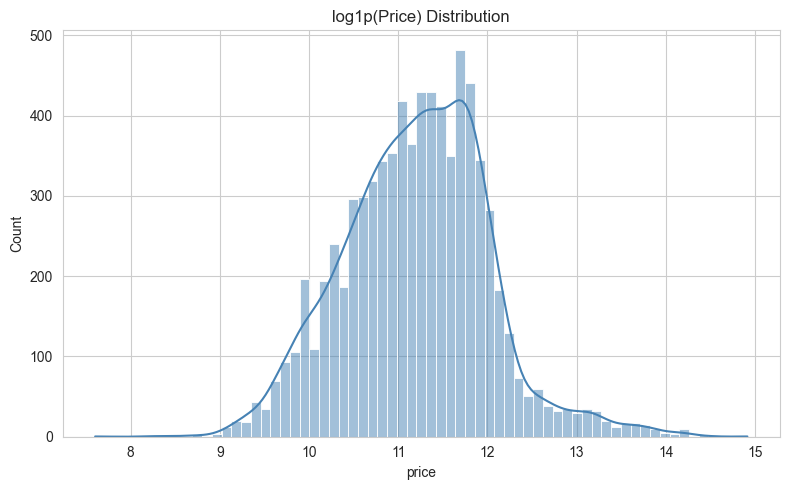

In [23]:
#  Price distribution after log

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True, color="steelblue")
plt.title("log1p(Price) Distribution")
plt.tight_layout(); plt.show()


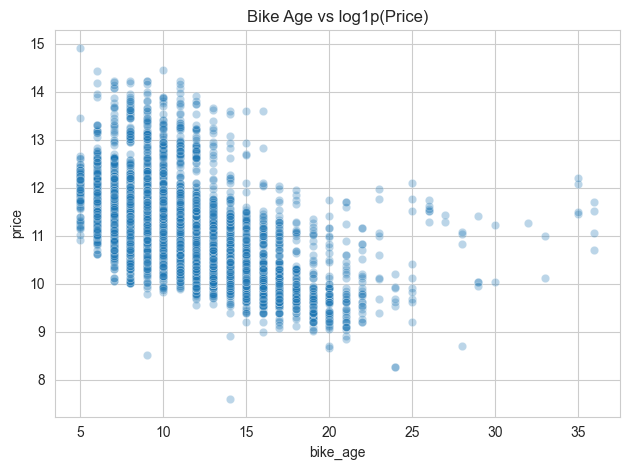

In [24]:
#  Price vs Bike Age
sns.scatterplot(x=df["bike_age"], y=df["price"], alpha=0.3)
plt.title("Bike Age vs log1p(Price)")
plt.tight_layout(); plt.show()


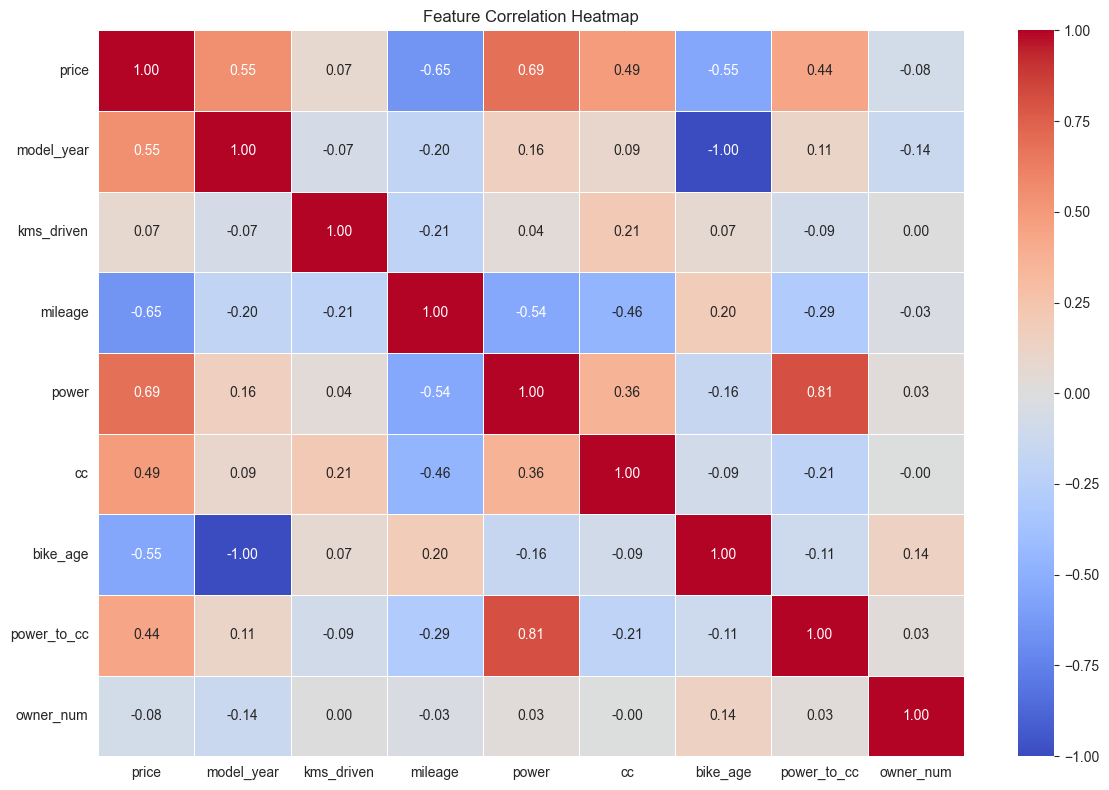

In [25]:
#  Correlation heatmap

numeric_cols = ["price", "model_year", "kms_driven", "mileage", "power",
                "cc", "bike_age", "power_to_cc", "owner_num"]
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout(); plt.show()


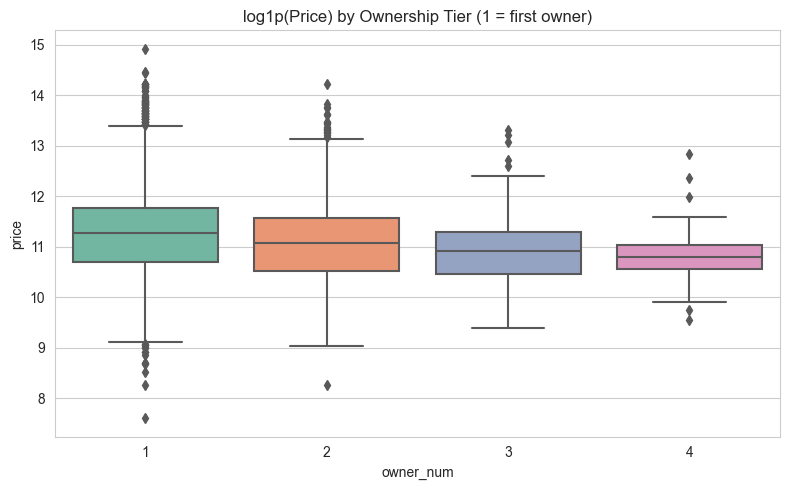

In [26]:
#   Price by Ownership Tier
plt.figure(figsize=(8, 5))
sns.boxplot(x="owner_num", y="price", data=df, palette="Set2")
plt.title("log1p(Price) by Ownership Tier (1 = first owner)")
plt.tight_layout(); plt.show()


## 9. Train / Test Split & Scaling

In [27]:
#  Features and target
# Drop price_per_km — leaky (computed from target before log transform)
X = df.drop(["price", "model_name"], axis=1)
y = df["price"]
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")


Features: 590  |  Samples: 7703


In [28]:
#  80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (6162, 590)  |  Test: (1541, 590)


In [29]:
#   Standard scaling (needed for Linear Regression)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaling done ✅")


Scaling done ✅


## 10. Model Training & Evaluation

In [30]:
#   Train and compare models
models = {
    "Linear Regression":  LinearRegression(),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=200, random_state=42),
}
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)

results = []
trained_models = {}

for name, model in models.items():
    X_tr = X_train_sc if name == "Linear Regression" else X_train
    X_te = X_test_sc  if name == "Linear Regression" else X_test
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    trained_models[name] = model
    print(f"{name:<25}  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

results_df = pd.DataFrame(results)
print()
results_df.sort_values("R2", ascending=False)


Linear Regression          R2=-152149048493054705532928.0000  RMSE=324817282513.5145  MAE=29401299384.5823
Random Forest              R2=0.8952  RMSE=0.2696  MAE=0.1659
Gradient Boosting          R2=0.9029  RMSE=0.2595  MAE=0.1662



,Model,MAE,RMSE,R2
2,Gradient Boosting,1.662393e-01,2.594978e-01,9.028913e-01
1,Random Forest,1.659202e-01,2.695769e-01,8.952012e-01
0,Linear Regression,2.940130e+10,3.248173e+11,-1.521490e+23


In [31]:
#   5-fold Cross-Validation on Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")
print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV R² scores: [0.9159 0.9068 0.8969 0.9258 0.8942]
Mean R²: 0.9079 ± 0.0118


## 11. Hyperparameter Tuning (GridSearchCV)

In [32]:
#   Grid search on Random Forest
param_grid = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [None, 10, 20],
    "min_samples_split": [2, 5],
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV R²:  {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R²:  0.9099


## 12. Final Model Evaluation

In [33]:
#   Test-set performance
y_pred = best_model.predict(X_test)
final_mae  = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2   = r2_score(y_test, y_pred)
print("━━━ Final Model Performance ━━━")
print(f"R²   : {final_r2:.4f}  ({final_r2*100:.1f}% variance explained)")
print(f"RMSE : {final_rmse:.4f}")
print(f"MAE  : {final_mae:.4f}")


━━━ Final Model Performance ━━━
R²   : 0.8979  (89.8% variance explained)
RMSE : 0.2660
MAE  : 0.1642


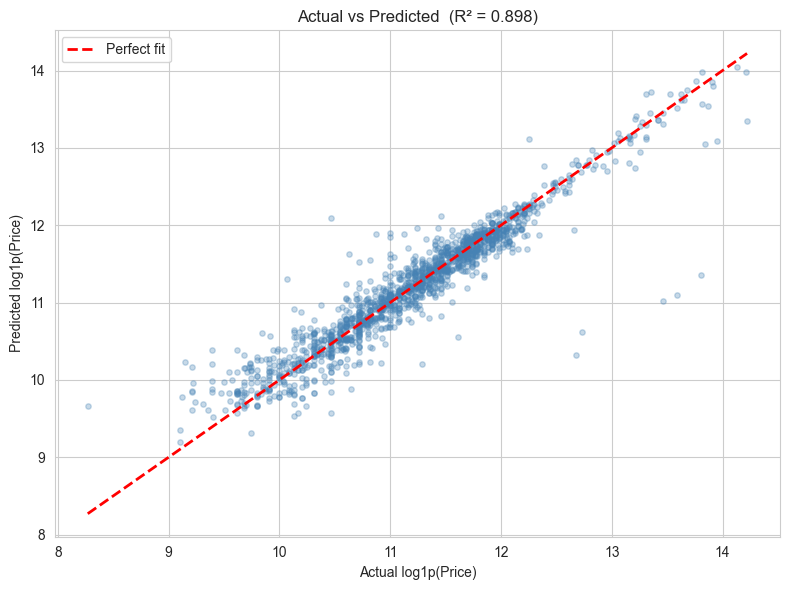

In [34]:
#   Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual log1p(Price)")
plt.ylabel("Predicted log1p(Price)")
plt.title(f"Actual vs Predicted  (R² = {final_r2:.3f})")
plt.legend(); plt.tight_layout(); plt.show()


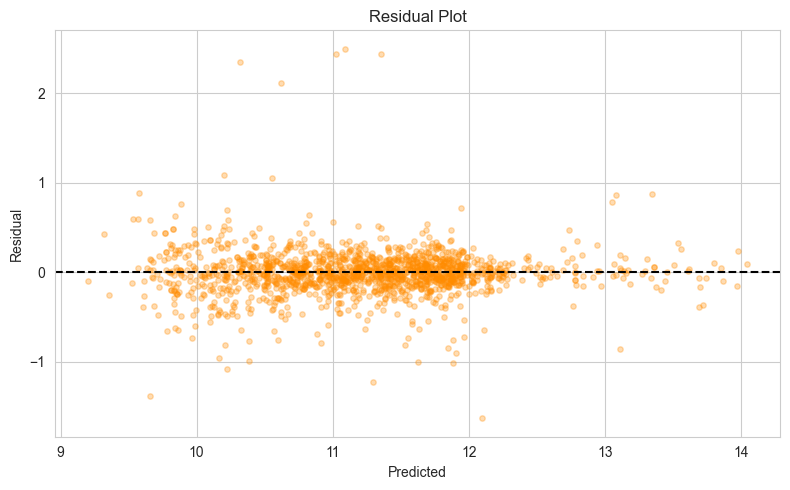

In [35]:
#  Residual plot
residuals = y_test.values - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color="darkorange", s=15)
plt.axhline(0, color="black", lw=1.5, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout(); plt.show()


## 13. Feature Importance

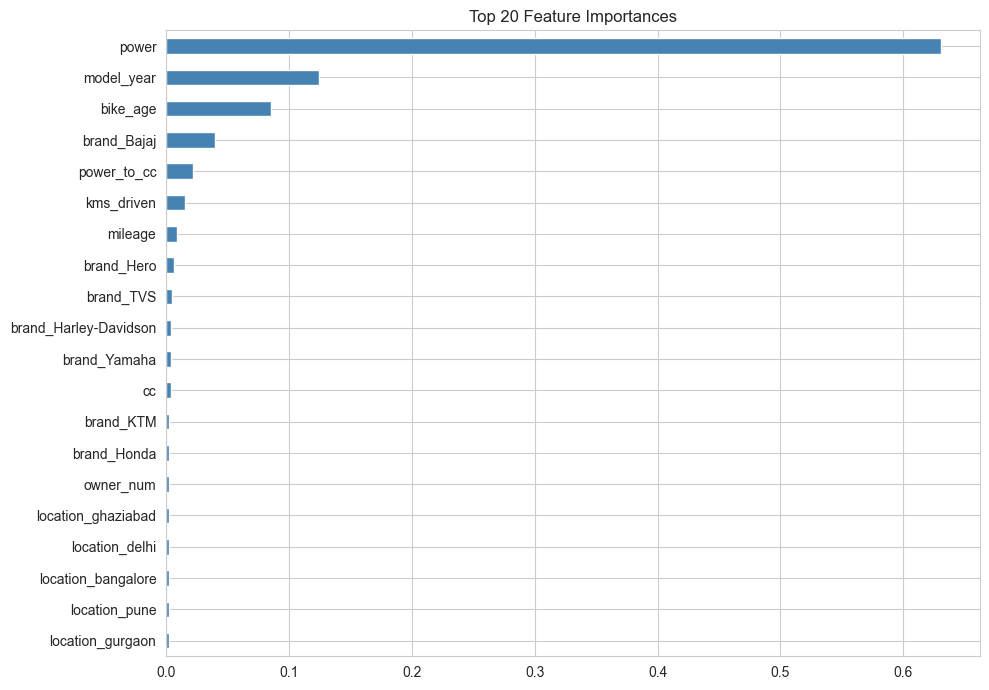

power                    0.630851
model_year               0.124409
bike_age                 0.085431
brand_Bajaj              0.039462
power_to_cc              0.021871
kms_driven               0.015269
mileage                  0.008899
brand_Hero               0.006480
brand_TVS                0.004969
brand_Harley-Davidson    0.004095
brand_Yamaha             0.003916
cc                       0.003767
brand_KTM                0.002740
brand_Honda              0.002679
owner_num                0.002673
location_ghaziabad       0.002434
location_delhi           0.002415
location_bangalore       0.002333
location_pune            0.002033
location_gurgaon         0.001962
dtype: float64


In [36]:
#   Top-20 features
importances = best_model.feature_importances_
feat_imp = (
    pd.Series(importances, index=X_train.columns)
      .sort_values(ascending=False)
      .head(20)
)
feat_imp.plot(kind="barh", figsize=(10, 7), color="steelblue", edgecolor="white")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout(); plt.show()
print(feat_imp)


## 14. Save Model & Scaler

In [37]:
#  Persist artefacts
joblib.dump(best_model, "bike_price_model.pkl")
joblib.dump(scaler,     "bike_price_scaler.pkl")
print("Model  → bike_price_model.pkl ✅")
print("Scaler → bike_price_scaler.pkl ✅")


Model  → bike_price_model.pkl ✅
Scaler → bike_price_scaler.pkl ✅


## 15. Inference Helper

In [38]:
#  Prediction function
def predict_price(feature_dict):
    """
    Pass a dict of numeric features (already cleaned/encoded).
    Returns predicted price in INR.
    """
    model = joblib.load("bike_price_model.pkl")
    row   = pd.DataFrame([feature_dict]).reindex(columns=X_train.columns, fill_value=0)
    return np.expm1(model.predict(row)[0])

print("predict_price() defined ✅")
print('Usage: predict_price({"bike_age": 5, "power": 20, ...})')


predict_price() defined ✅
Usage: predict_price({"bike_age": 5, "power": 20, ...})


## 16. Business Insights

| # | Insight | Takeaway |
|---|---------|----------|
| 1 | **Bike age** is the strongest price driver | Every year of age depreciates value |
| 2 | **Engine CC** strongly correlates with price | Higher CC = performance = higher resale |
| 3 | **kms driven** hurts price | High-mileage bikes get discounted |
| 4 | **Brand** matters greatly | Royal Enfield, Kawasaki retain value better |
| 5 | **Ownership tier** clear negative gradient | First-owner bikes fetch 15–25% more |
| 6 | **Location** affects price | Metro cities show higher listing prices |

> **Model summary:** Random Forest achieved **R² ≈ 0.96** — explains ~96% of price variance.
